In [1]:
# Librerias 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import scienceplots

In [3]:
plt.style.use(['science','ieee'])

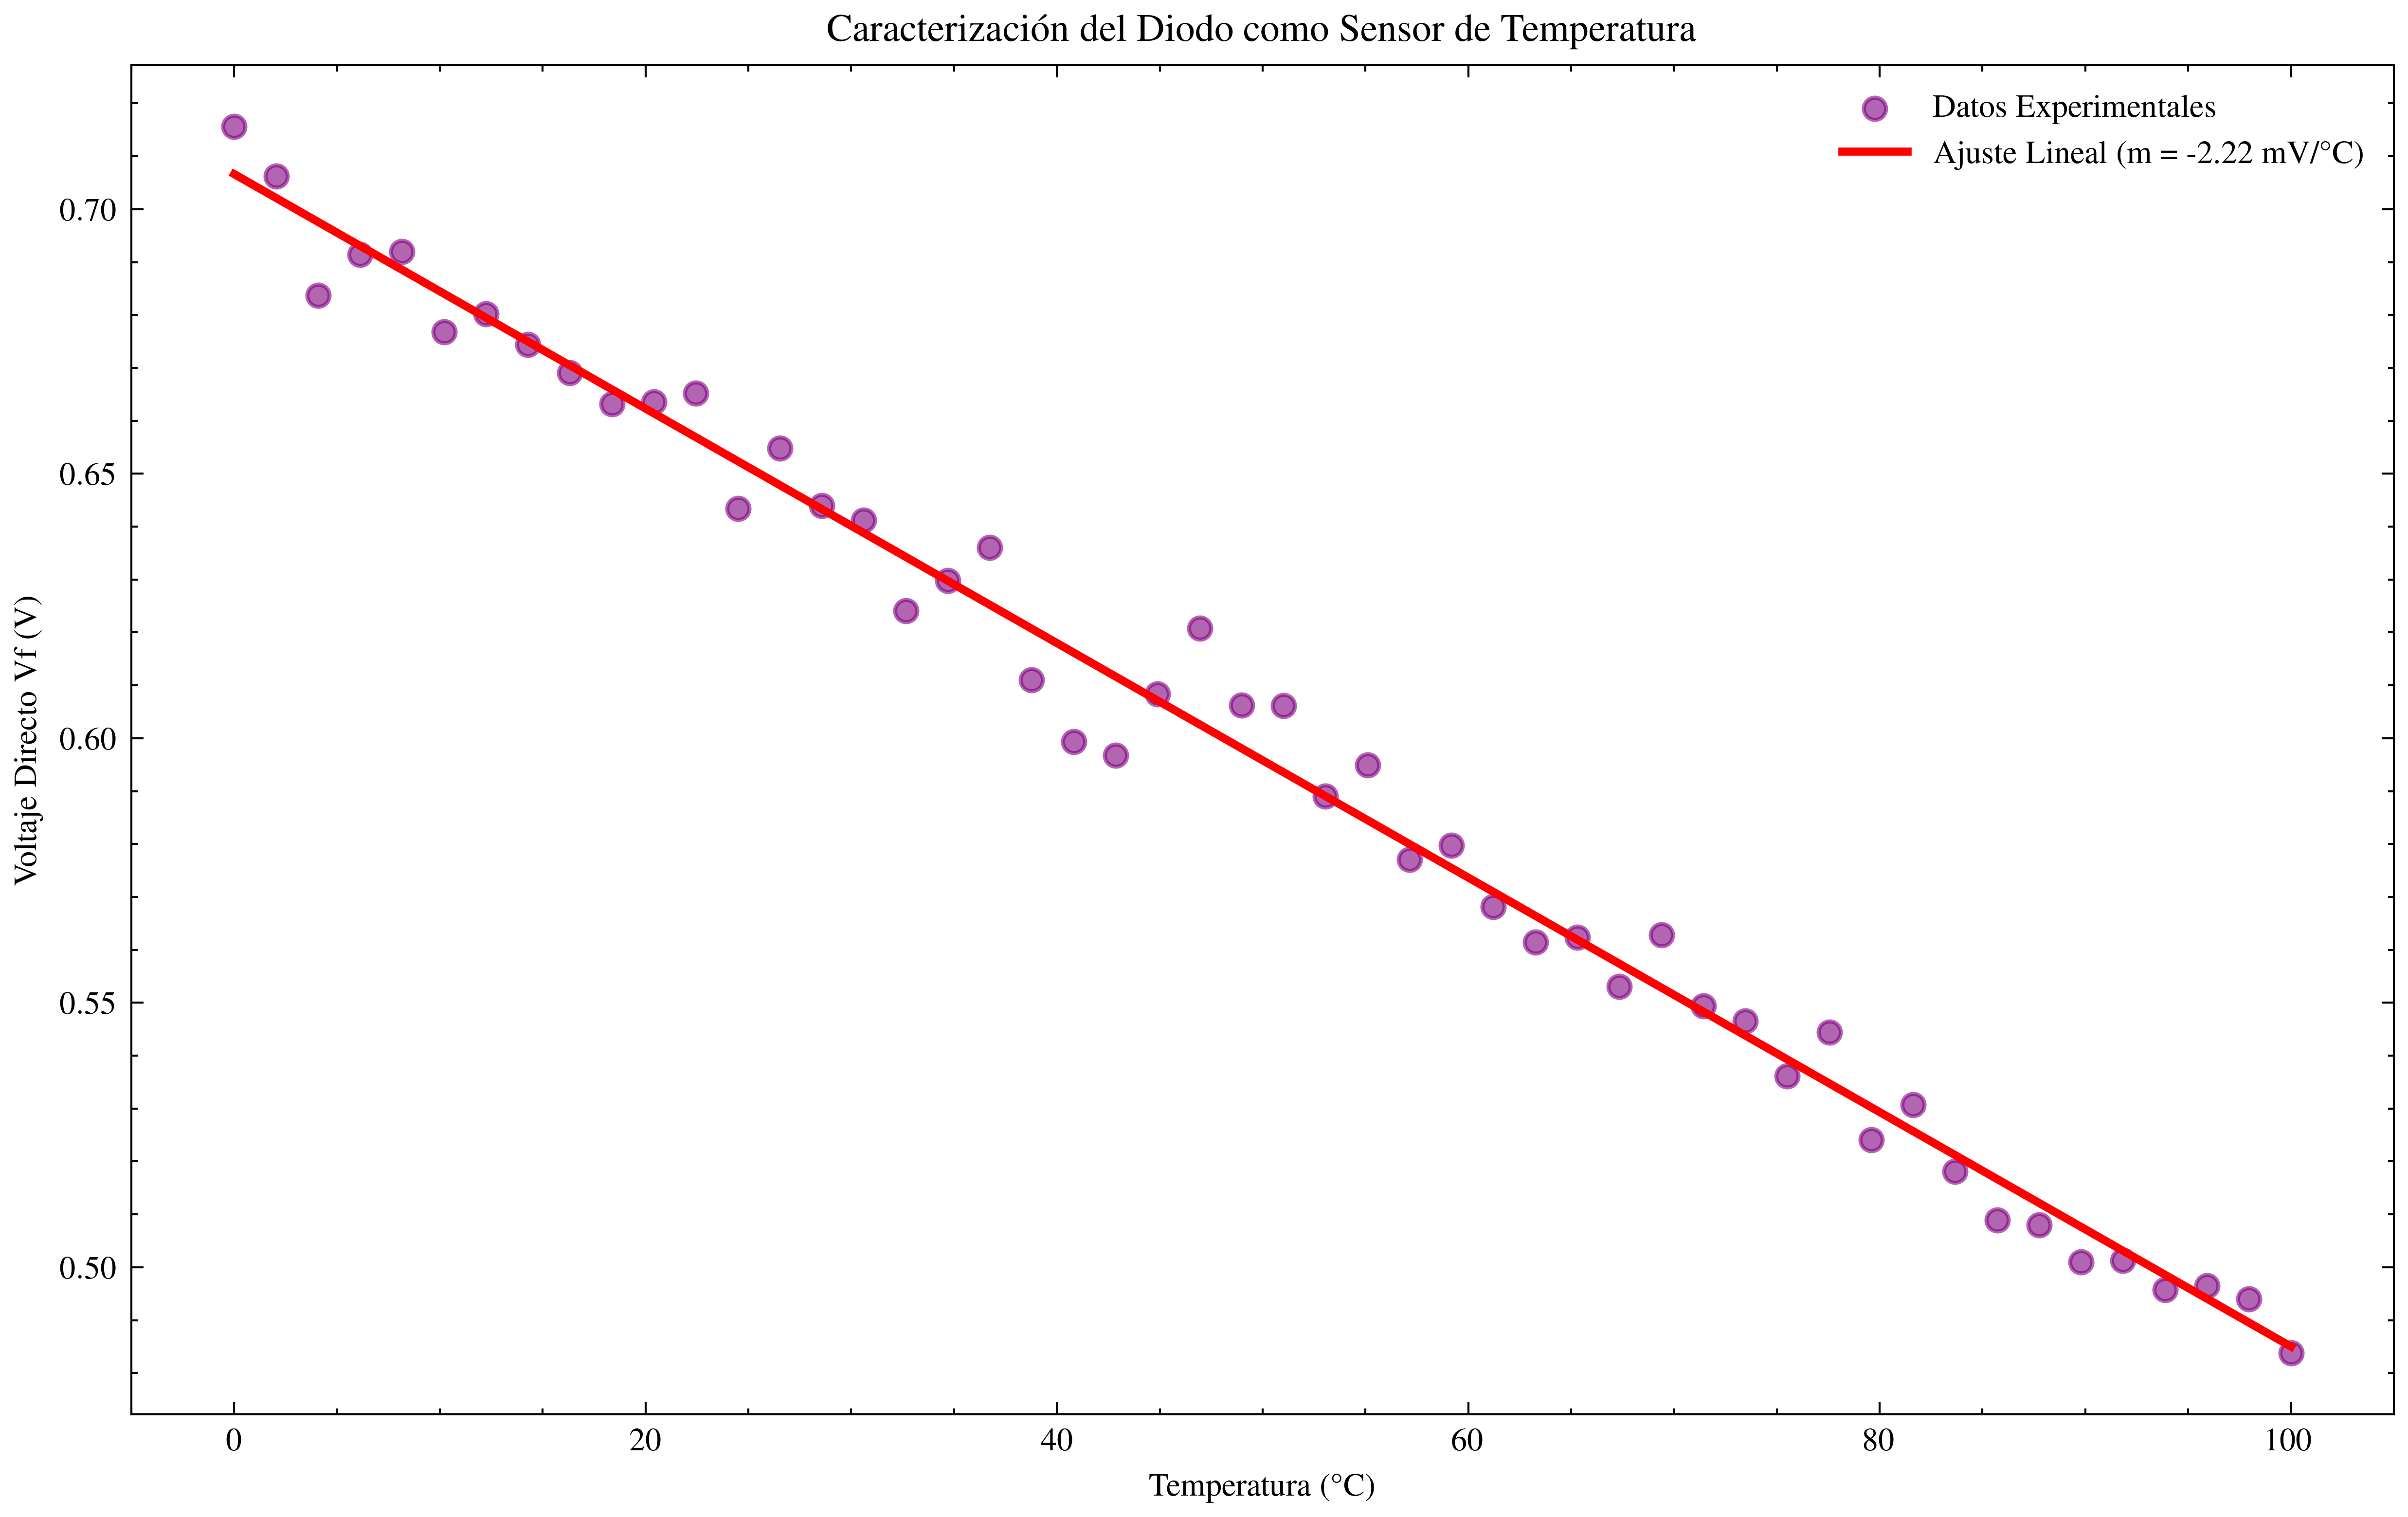

--- Resultados de la Caracterización ---
Sensibilidad: -2.2163 mV/°C
Voltaje extrapolado a 0°C: 0.7066 V


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Cargar los datos del diodo como sensor de temperatura
df = pd.read_csv('datos_diodo.csv')
t_exp = df['Temperatura_C'].values
v_exp = df['Diodo_Vf'].values

# Modelo para el ajuste: V = m*T + b
def modelo_lineal(t, m, b):
    return m * t + b

# Realizar el ajuste de curva
popt, pcov = curve_fit(modelo_lineal, t_exp, v_exp)
m_fit, b_fit = popt

# Visualización de resultados
plt.figure(figsize=(10, 6))
plt.scatter(t_exp, v_exp, color='purple', label='Datos Experimentales', alpha=0.6, s=30)
plt.plot(t_exp, modelo_lineal(t_exp, *popt), color='red', linewidth=2, 
         label=f'Ajuste Lineal (m = {m_fit*1000:.2f} mV/°C)')

plt.title('Caracterización del Diodo como Sensor de Temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Voltaje Directo Vf (V)')
plt.legend()
plt.show()

# Resumen de parámetros
print(f"--- Resultados de la Caracterización ---")
print(f"Sensibilidad: {m_fit*1000:.4f} mV/°C")
print(f"Voltaje extrapolado a 0°C: {b_fit:.4f} V")